# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Cindy Nabella Susanto
- **Email:** cindynabella29@gmail.com
- **ID Dicoding:** cindy_nabella

## Menentukan Pertanyaan Bisnis

- Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara jam sibuk (Working Hours) dan jam santai (Rest Hours) berdasarkan data historis untuk menentukan alokasi unit sepeda yang efisien?
- Musim apa yang menunjukkan penurunan performa penyewaan sepeda paling signifikan bagi pengguna Casual dibandingkan pengguna Registered untuk mengoptimalkan strategi promosi musiman?

## Import Semua Packages/Library yang Digunakan

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

## Data Wrangling

### Gathering Data

In [17]:
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

print("Jumlah data harian:", day_df.shape)
print("Jumlah data per jam:", hour_df.shape)

display(day_df.head())
display(hour_df.head())

Jumlah data harian: (731, 16)
Jumlah data per jam: (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Terdapat dua file csv yang akan digunakan sebagai dataset pada kasus ini. Dataset ```day.csv``` merupakan ringkasan data rental sepeda per hari, sedangkan ```hour.csv``` merupakan detail harian yang menunjukkan data pada setiap jam.
- Dataset ```day.csv``` memiliki 731 baris yang merepresentasikan data harian selama dua tahun (2011-2012). Sementara itu, dataset ```hour.csv``` memiliki volume data yang jauh lebih besar, yaitu 17.379 baris, karena menyajikan rincian data peminjaman pada tingkat jam.

### Assessing Data

In [18]:
display(day_df.info())
display(hour_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


None

In [19]:
print(f"Jumlah missing value pada day.csv: \n{day_df.isnull().sum()} \n")
print(f"Jumlah missing value pada hour.csv: \n{hour_df.isnull().sum()} \n")

Jumlah missing value pada day.csv: 
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64 

Jumlah missing value pada hour.csv: 
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64 



In [20]:
print(f"Jumlah data duplikat pada day.csv: {day_df.duplicated().sum()} \n")
print(f"Jumlah data duplikat pada hour.csv: {hour_df.duplicated().sum()} \n")

Jumlah data duplikat pada day.csv: 0 

Jumlah data duplikat pada hour.csv: 0 



In [21]:
display(day_df.describe())
display(hour_df.describe())

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Data sudah bersih, tidak ada missing value maupun duplikat data pada kedua dataset
- Rata-rata penyewaan sepeda terjadi di antara musim panas dan musim gugur
- Berdasarkan ```day.csv```, nilai minimum penyewaan adalah 22. Hal ini mengindikasikan bahwa layanan selalu digunakan setiap harinya selama periode 2 tahun, tanpa ada satu pun hari dengan nol transaksi.

### Cleaning Data

**Insight:**
- Berdasarkan tahap assessing data, dapat dilihat bahwa dataset tersebut sudah bersih dengan indikasi
    - Tidak terdapat missing value
    - Tidak memiliki duplikasi data
    - Tipe data sudah sesuai
    - Value untuk setiap fitur sudah sesuai kriteria pada readme dataset

## Exploratory Data Analysis (EDA)

### Explore distribusi Jumlah Penyewa Per Hari

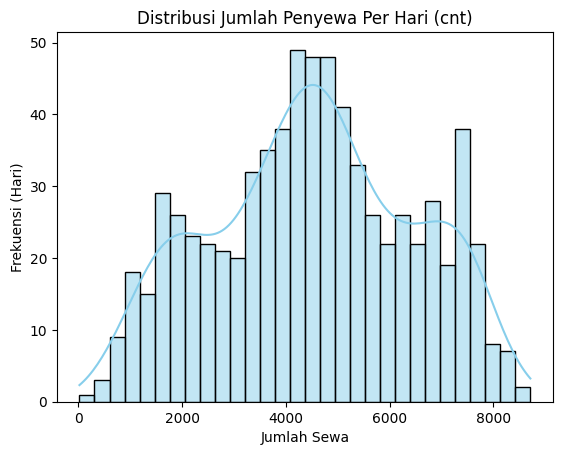

In [22]:
sns.histplot(day_df['cnt'], bins=30, kde=True, color='skyblue')
plt.title("Distribusi Jumlah Penyewa Per Hari (cnt)")
plt.xlabel("Jumlah Sewa")
plt.ylabel("Frekuensi (Hari)")
plt.show()

**Insight:**
- Dapat dilihat bahwa persebaran jumlah penyewaan dari dataset tersebut memiliki distribusi normal dengan rata-rata penyewaan 4000-5000 per hari.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9612\1419297138.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='season_label', data=day_df, order=['Spring', 'Summer', 'Fall', 'Winter'], palette='pastel', ax=ax[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9612\1419297138.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather_label', data=day_df, palette='coolwarm', ax=ax[1])


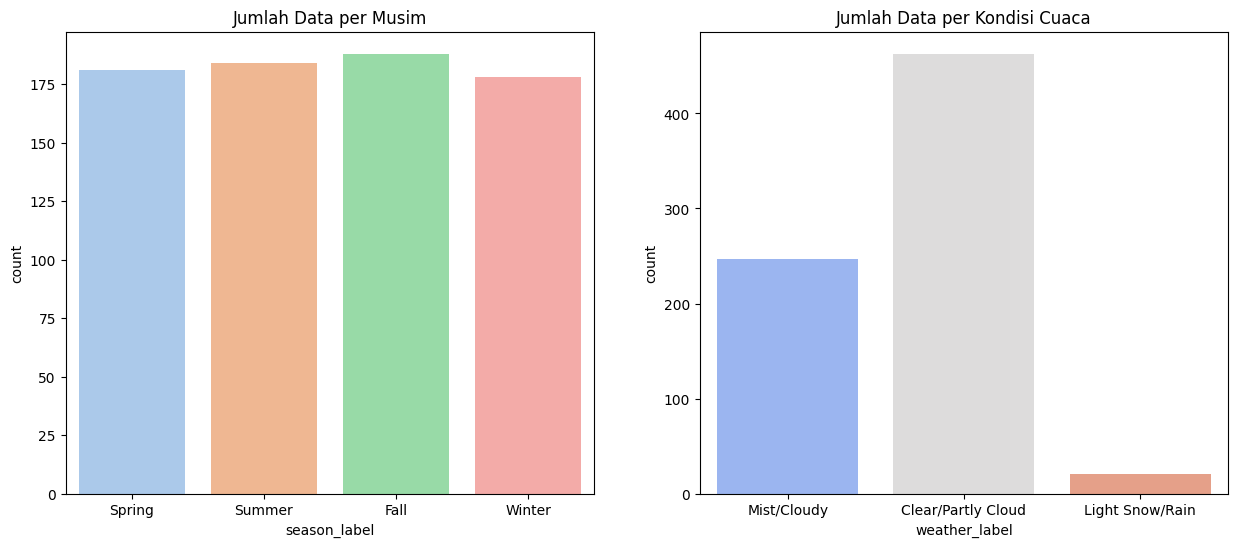

In [23]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear/Partly Cloud', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Severe Weather'}

day_df['season_label'] = day_df['season'].map(season_map)
day_df['weather_label'] = day_df['weathersit'].map(weather_map)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x='season_label', data=day_df, order=['Spring', 'Summer', 'Fall', 'Winter'], palette='pastel', ax=ax[0])
ax[0].set_title("Jumlah Data per Musim")

sns.countplot(x='weather_label', data=day_df, palette='coolwarm', ax=ax[1])
ax[1].set_title("Jumlah Data per Kondisi Cuaca")

plt.show()

**Insight:**
- Jumlah data (hari) tersebar merata di keempat musim. Setiap musim memiliki proporsi jumlah hari yang seimbang.
- Kondisi cuaca didominasi oleh kategori 1 (Clear/Partly Cloud), diikuti oleh kategori 2 (Mist/Cloudy).
- Kategori 3 (Light Snow/Rain) memiliki jumlah data yang sangat sedikit. Ini menunjukkan bahwa kondisi cuaca buruk relatif jarang terjadi dibandingkan hari cerah selama periode pengamatan.
- Sebagai tambahan, pada catatan dataset terdapat cuaca dengan nilai 4, yaitu untuk cuaca ekstrem. Namun, tidak ada data dengan cuaca tersebut pada dataset. Hal ini kemungkinan terjadi karena dataset ini adalah ringkasan harian (day.csv). Cuaca ekstrem biasanya terjadi dalam durasi pendek (hitungan jam), sehingga ketika dirata-rata menjadi data harian, labelnya tidak mencapai kategori ekstrem.

### Explore outlier pada day.csv

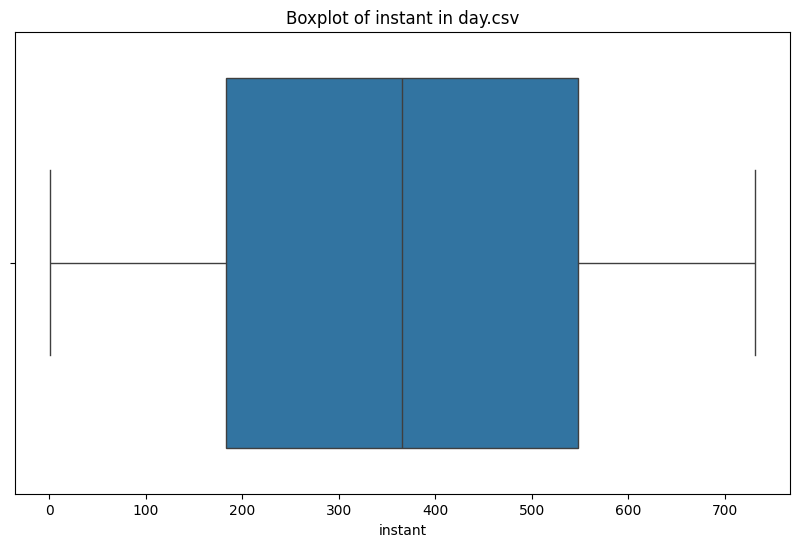

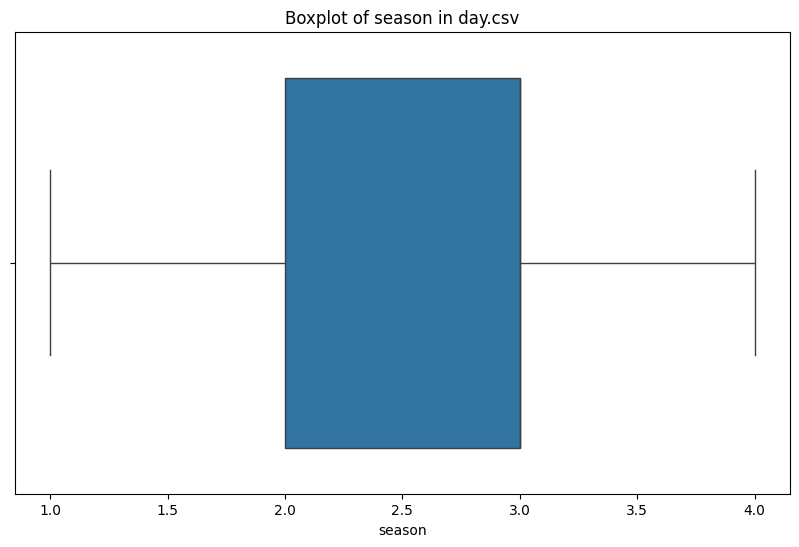

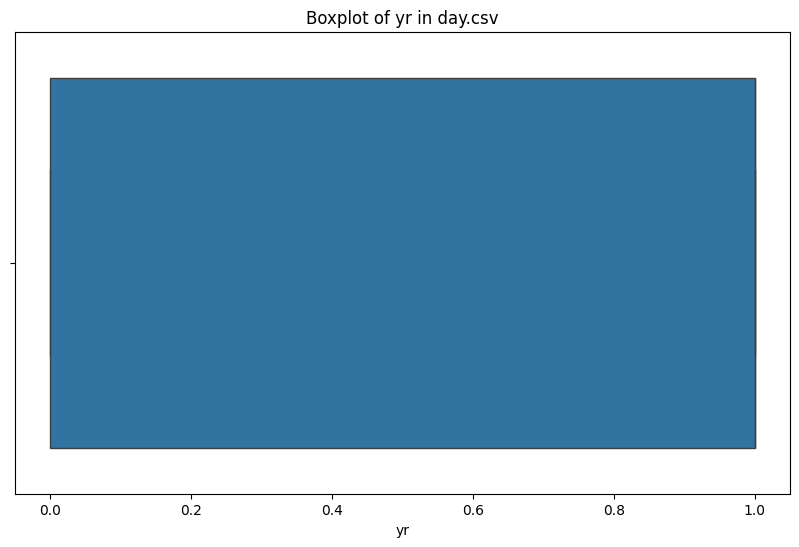

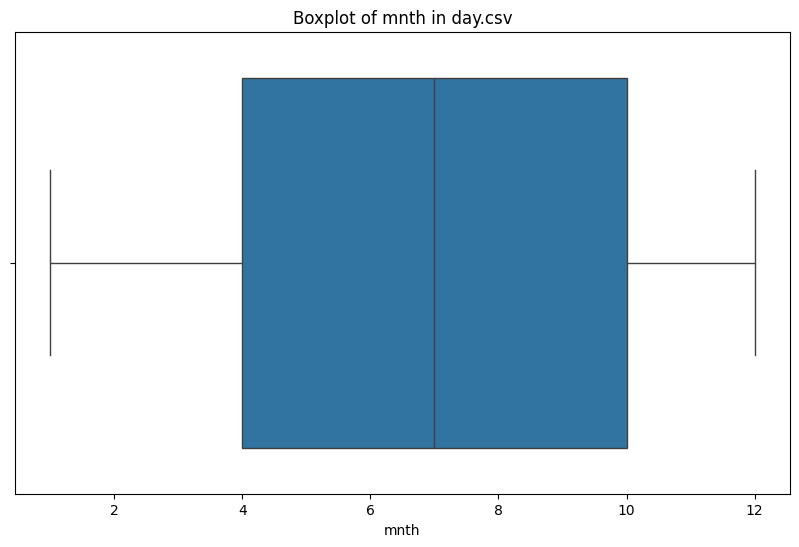

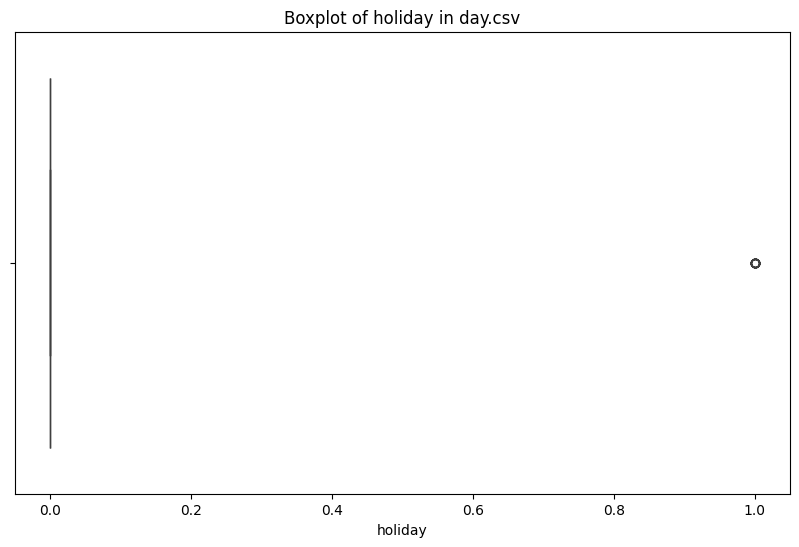

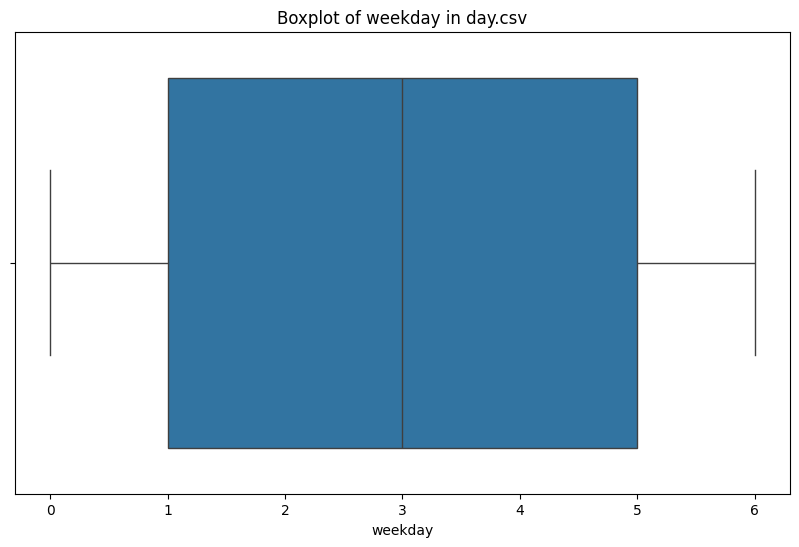

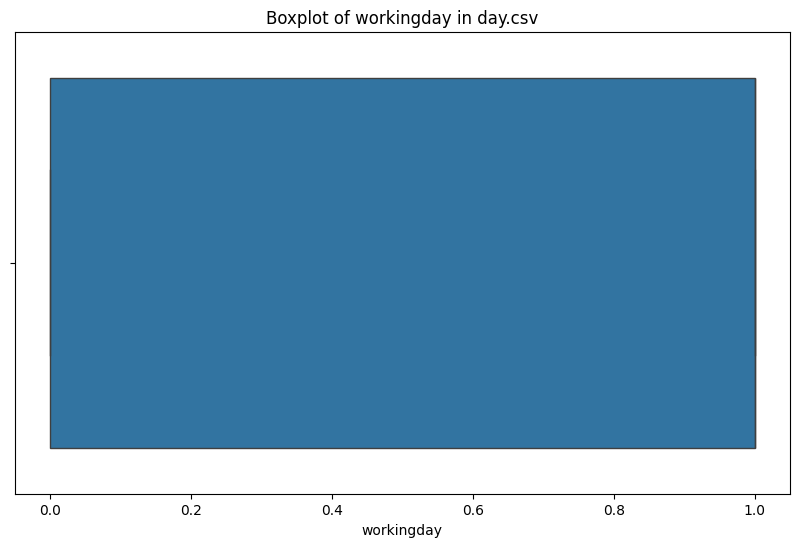

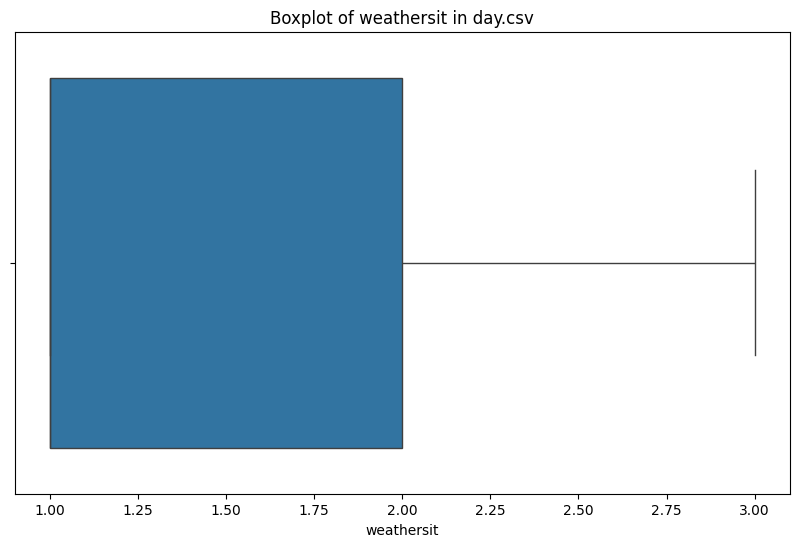

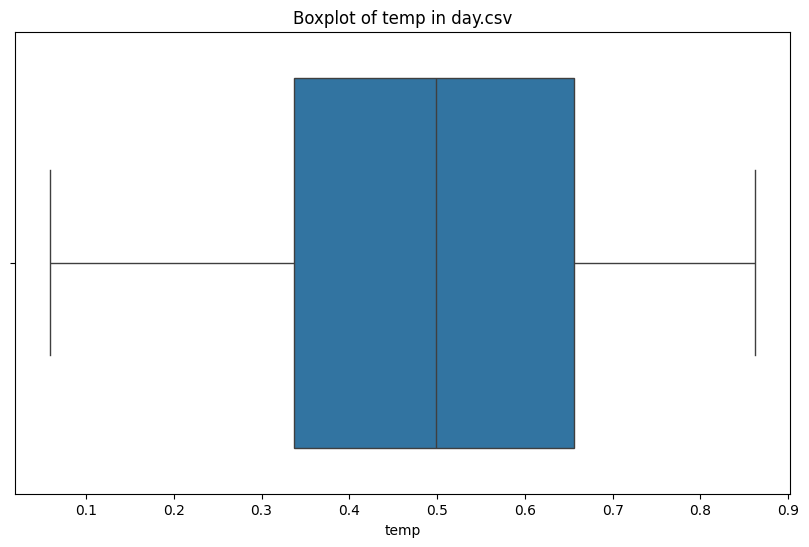

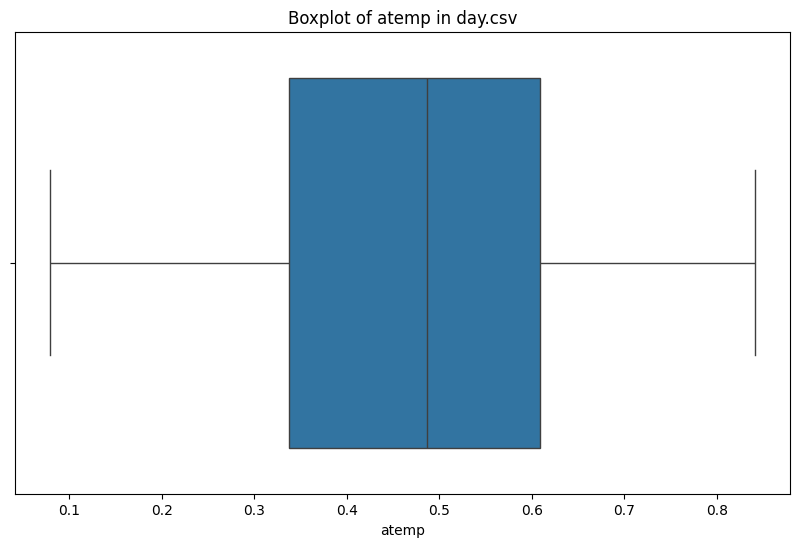

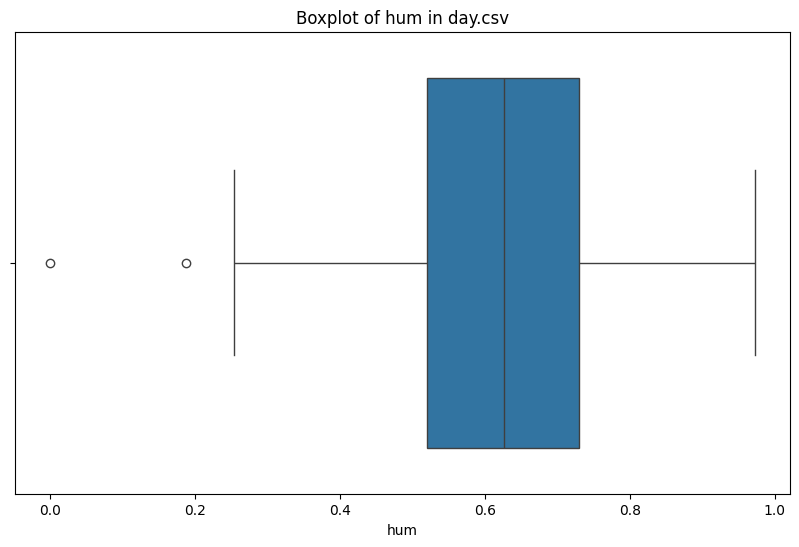

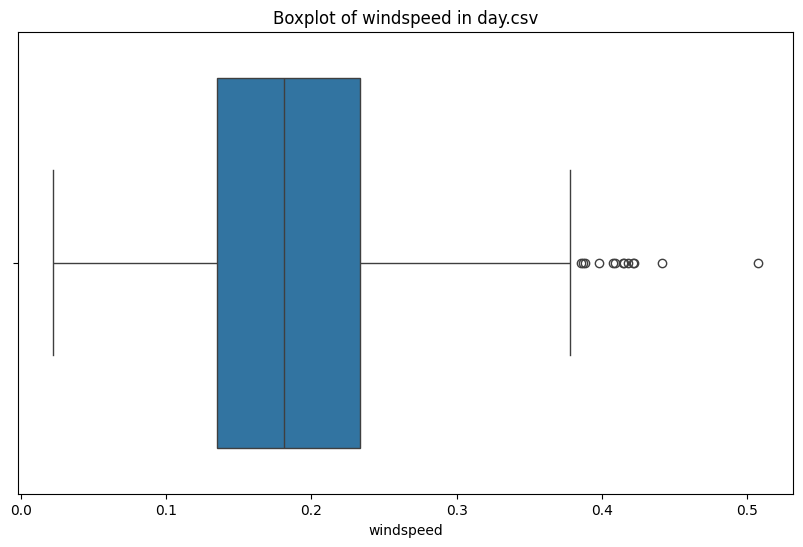

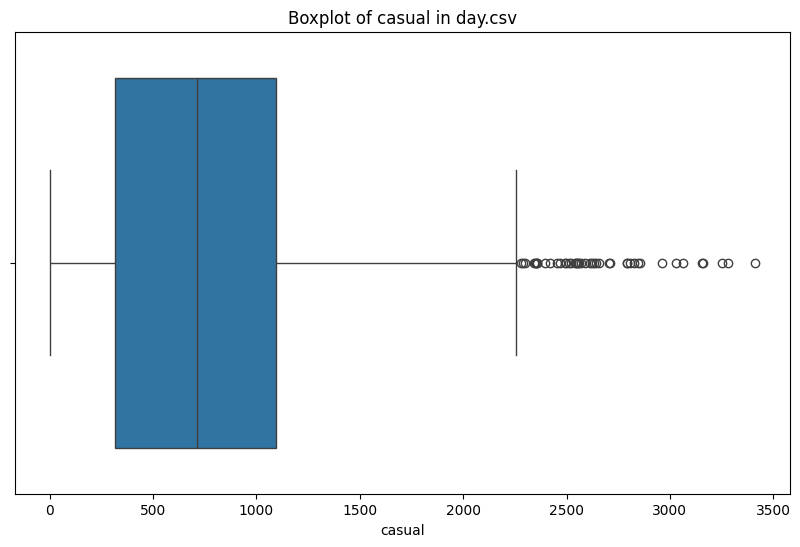

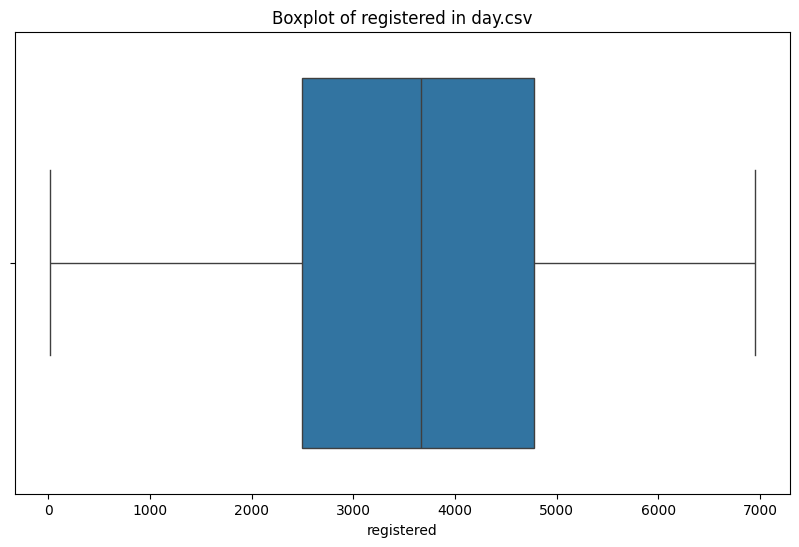

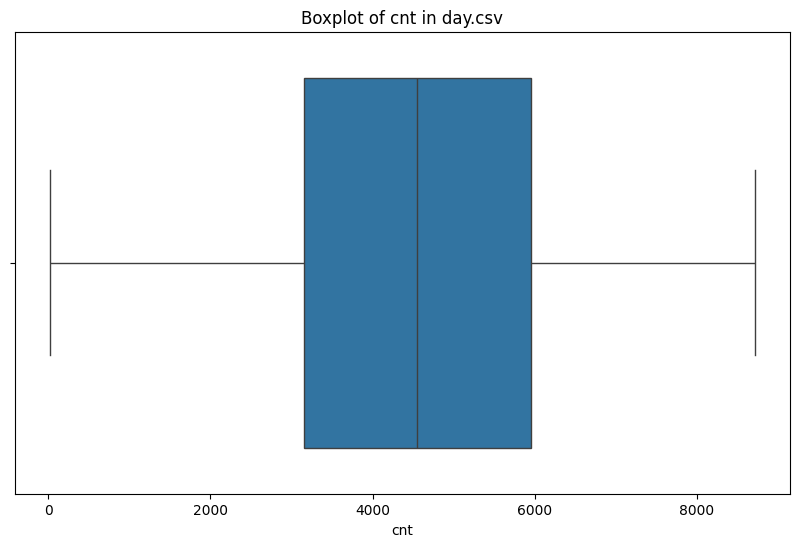

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [24]:
day_numeric_features = day_df.select_dtypes(include=['float64', 'int64']).columns

for feature in day_numeric_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=day_df[feature])
    plt.title(f'Boxplot of {feature} in day.csv')
    plt.show()

display(day_df.describe())


**Insight:**
- Mayoritas fitur numerik menunjukkan distribusi yang normal dan bersih, tanpa indikasi outlier yang signifikan.
- Outlier terbanyak dimiliki oleh fitur ```casual```. Hal ini sangat mungkin terjadi dikarenakan pengguna yang bukan member, tidak memiliki pola penggunaan yang rutin seperti pengguna terdaftar. Nilai outlier ini kemungkinan besar merepresentasikan lonjakan permintaan yang drastis pada hari libur atau akhir pekan.
- Variabel ```windspeed``` juga memiliki beberapa outlier. Hal ini merepresentasikan perubahan kondisi alam yang wajar, di mana kecepatan angin dapat meningkat secara signifikan pada waktu-waktu tertentu.

### Explore Tren Penyewaan Sepeda Harian

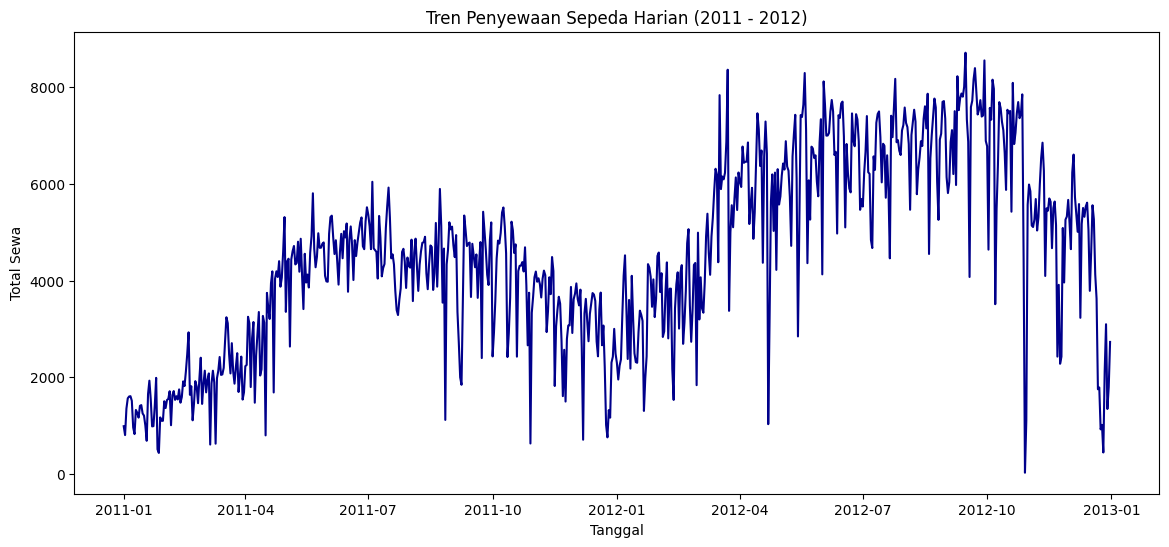

In [25]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

plt.figure(figsize=(14, 6))
sns.lineplot(x='dteday', y='cnt', data=day_df, color='darkblue')

plt.title("Tren Penyewaan Sepeda Harian (2011 - 2012)")
plt.xlabel("Tanggal")
plt.ylabel("Total Sewa")
plt.show()

**Insight:**
- Dapat dilihat tren peningkatan yang signifikan dari tahun 2011 ke 2012. Jumlah penyewaan pada tahun 2012 secara konsisten lebih tinggi dibandingkan periode yang sama di tahun sebelumnya, menandakan bertambahnya basis pengguna dan popularitas layanan.
- Terdapat pola siklus yang jelas. Penyewaan mencapai puncak pada pertengahan tahun dan menyentuh titik terendah di awal serta akhir tahun. Hal ini mengonfirmasi bahwa faktor musim memiliki dampak terhadap permintaan.
- Terdapat beberapa penurunan tajam pada grafik yang kemungkinan besar disebabkan oleh kondisi cuaca buruk atau kejadian khusus pada hari tersebut.

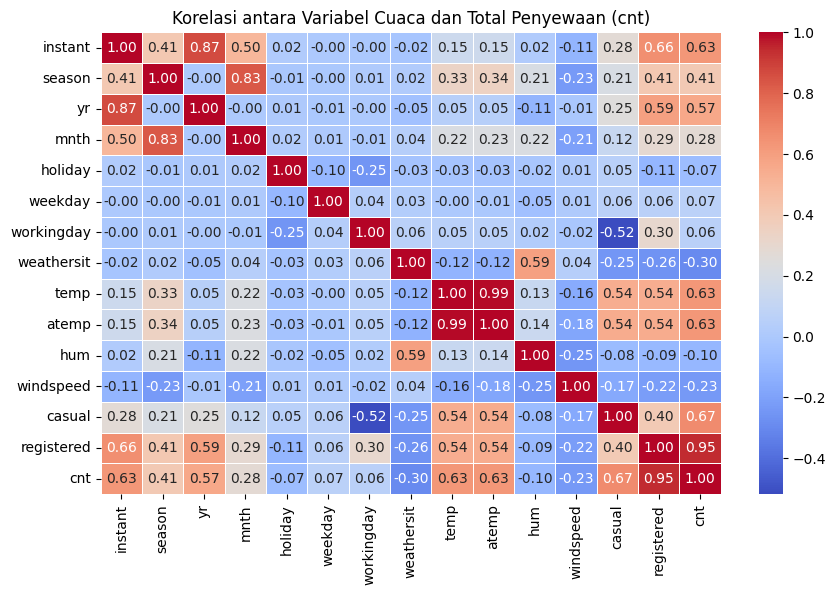

In [26]:
plt.figure(figsize=(10, 6))

correlation_matrix = day_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Korelasi antara Variabel Cuaca dan Total Penyewaan (cnt)")
plt.show()

**Insight:**
- Variabel ```temp``` dan ```atemp``` memiliki korelasi positif tertinggi terhadap ```cnt```. Hal ini mengindikasikan bahwa suhu hangat adalah faktor utama tingginya minat bersepeda.
- Kelembaban ```hum``` dan kecepatan angin ```windspeed``` memiliki korelasi negatif. Hal ini berarti bahwa cuaca yang terlalu lembab atau berangin kencang cenderung menurunkan jumlah penyewaan, meskipun pengaruhnya tidak sebesar suhu.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbedaan rata-rata jumlah penyewaan sepeda antara jam sibuk (Working Hours) dan jam santai (Rest Hours) berdasarkan data historis untuk menentukan alokasi unit sepeda yang efisien?

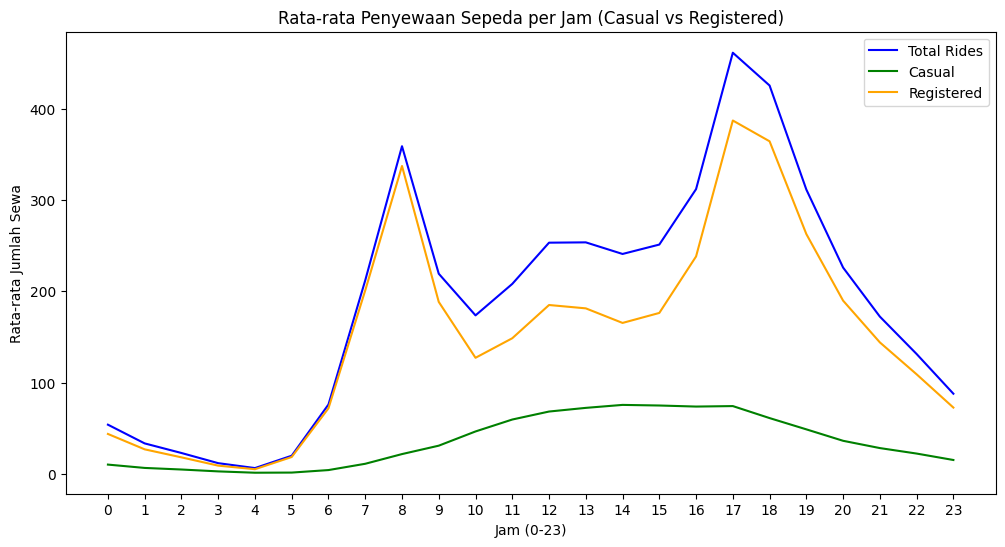

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', data=hour_df, label='Total Rides', color='blue', errorbar=None)
sns.lineplot(x='hr', y='casual', data=hour_df, label='Casual', color='green', errorbar=None)
sns.lineplot(x='hr', y='registered', data=hour_df, label='Registered', color='orange', errorbar=None)

plt.title("Rata-rata Penyewaan Sepeda per Jam (Casual vs Registered)")
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Jumlah Sewa")
plt.legend()
plt.xticks(range(0, 24))
plt.show()

**Insight:**
- Identifikasi Jam Sibuk:
    - Visualisasi menunjukkan pola yang sangat jelas pada total penyewaan.
    - Puncak Pagi: Terjadi pada pukul 08:00 (rata-rata 360 sewa).
    - Puncak Sore: Terjadi pada pukul 17:00-18:00 (rata-rata 450 sewa).
    - Pola ini mengonfirmasi bahwa penggunaan sepeda aktif pada jam keberangkatan dan kepulangan kantor/sekolah.
- Perbedaan Perilaku Pengguna:
    - Registered User: Mengikuti pola jam kerja, dimana penyewaan naik tajam pagi & sore dan turun saat jam kerja/makan siang. Ini menunjukkan mereka menggunakan sepeda sebagai transportasi utama.
    - Casual User: Memiliki pola yang berbeda, yaitu naik secara bertahap dan memuncak di siang hingga sore hari (12:00-16:00). Ini menunjukkan penggunaan untuk rekreasi/santai.
- Rekomendasi Alokasi:
    - Jam Sibuk (Working Hours): Alokasi unit harus dimaksimalkan pada jam 07:00 pagi dan 16:00 sore untuk mengantisipasi lonjakan. Proses pengisian ulang stok wajib dilakukan 1 jam sebelum puncak tersebut.
    - Jam Santai (Rest Hours): Pada jam 22:00-05:00, permintaan sangat rendah. Ini adalah waktu yang efisien untuk melakukan pemeliharaan atau mendistribusikan ulang sepeda tanpa mengganggu pengguna.

### Pertanyaan 2: Musim apa yang menunjukkan penurunan performa penyewaan sepeda paling signifikan bagi pengguna Casual dibandingkan pengguna Registered untuk mengoptimalkan strategi promosi musiman?

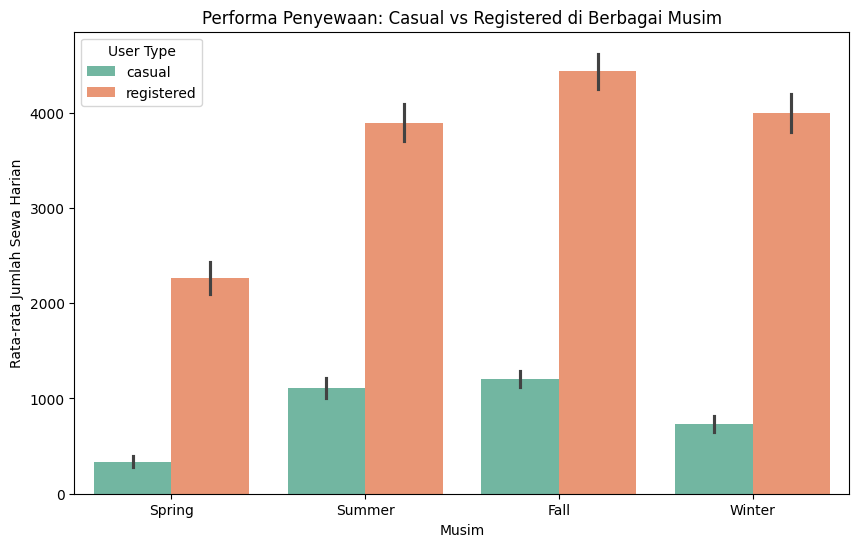

In [28]:
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_label'] = day_df['season'].map(season_mapping)

melted_season_df = day_df.melt(id_vars='season_label', 
                               value_vars=['casual', 'registered'], 
                               var_name='User Type', 
                               value_name='Rides')

plt.figure(figsize=(10, 6))
sns.barplot(x='season_label', y='Rides', hue='User Type', data=melted_season_df, palette='Set2')

plt.title("Performa Penyewaan: Casual vs Registered di Berbagai Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Jumlah Sewa Harian")
plt.show()

**Insight:**
- Identifikasi Penurunan Terbesar:
    - Musim Semi (Spring) adalah musim yang menunjukkan performa terburuk bagi kedua tipe pengguna. 
    - Pengguna Registered mengalami penurunan di Spring, tetapi jumlahnya masih cukup tinggi. Ini membuktikan bahwa pengguna Registered lebih kuat terhadap kondisi cuaca.
- Puncak Performa:
    - Musim Gugur (Fall) adalah musim dengan rata-rata penyewaan tertinggi untuk kedua kategori.
- Rekomendasi Strategi (Jawaban Pertanyaan Bisnis):
    - Pengguna Casual: Hindari melakukan promosi besar-besaran di Musim Semi (Spring) karena permintaannya rendah dan mereka enggan bersepeda karena cuaca, bukan karena harga. Alihkan budget promosi besar-besaran ke Musim Panas (Summer) dan Gugur (Fall) di mana minat mereka sedang tumbuh pesat.
    - Untuk Pengguna Registered: Di musim semi (Spring), fokuskan strategi pada Loyalty Program agar mereka tetap semangat menggunakan sepeda meskipun cuaca masih agak dingin.

## Analisis Lanjutan (Opsional)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9612\4256946277.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time_category', y='cnt', data=hour_df, order=order_time, palette='viridis', estimator='mean')


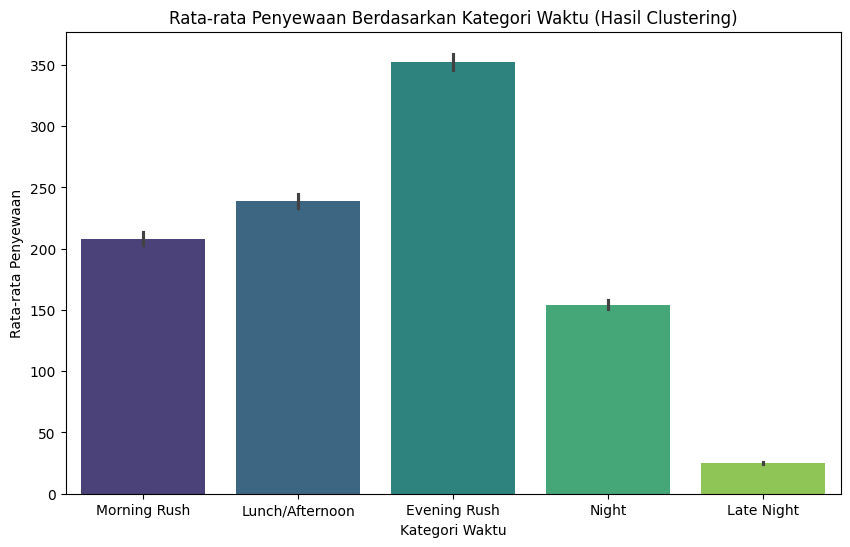

In [29]:
def categorize_time_of_day(hour):
    if 0 <= hour < 6:
        return 'Late Night'
    elif 6 <= hour < 11:
        return 'Morning Rush'
    elif 11 <= hour < 15:
        return 'Lunch/Afternoon'
    elif 15 <= hour < 20:
        return 'Evening Rush'
    else:
        return 'Night'

hour_df['time_category'] = hour_df['hr'].apply(categorize_time_of_day)

order_time = ['Morning Rush', 'Lunch/Afternoon', 'Evening Rush', 'Night', 'Late Night']

plt.figure(figsize=(10, 6))
sns.barplot(x='time_category', y='cnt', data=hour_df, order=order_time, palette='viridis', estimator='mean')
plt.title("Rata-rata Penyewaan Berdasarkan Kategori Waktu (Hasil Clustering)")
plt.xlabel("Kategori Waktu")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

**Insight:**
- Melalui teknik clustering waktu, terlihat bahwa Evening Rush adalah fase paling kritis yang membutuhkan ketersediaan unit maksimal karena melayani gabungan pengguna pulang kerja dan rekreasi. Sementara itu, fase Late Night yang sangat sepi harus dimanfaatkan sepenuhnya untuk operasional maintenance untuk menghindari downtime di jam sibuk.

In [30]:
day_df.to_csv("dashboard/day_clean.csv", index=False)
hour_df.to_csv("dashboard/hour_clean.csv", index=False)

## Conclusion

- Conclution pertanyaan 1:
    - Analisis menunjukkan perbedaan drastis antara jam sibuk dan santai, di mana terbentuk pola dengan puncak aktivitas tertinggi pada pukul 08:00 dan 17:00 yang didominasi oleh pengguna Registered. Oleh karena itu, alokasi unit sepeda harus diprioritaskan siap pakai satu jam sebelum waktu-waktu tersebut, sementara kegiatan teknis seperti perbaikan dan distribusi ulang sebaiknya dialihkan ke jam 00:00-05:00 di mana permintaan mendekati nol untuk menjaga efisiensi operasional.
- Conclution pertanyaan 2:
    - Musim Semi (Spring) teridentifikasi sebagai periode dengan penurunan performa paling signifikan bagi pengguna Casual, yang jauh lebih sensitif terhadap kondisi cuaca dibandingkan pengguna Registered. Hal ini mengindikasikan bahwa strategi untuk promosi besar-besaran kepada pengguna Casual tidak akan efektif di awal tahun. Anggaran pemasaran sebaiknya dialokasikan saat memasuki Musim Panas (Summer) dan Gugur (Fall) ketika minat bersepeda rekreasi mencapai potensi maksimalnya.